# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

In [29]:
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


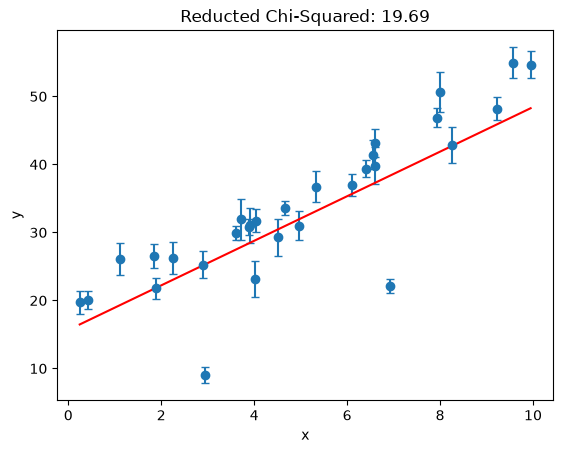

m:  3.276935099375491
m +-:  0.5343977128733114
b:  15.664164078095661
b +-:  2.8491519136530044
reduced chi-squared:  19.688793951814112


In [25]:
# Part 1: your work here
data = pd.read_csv('../../labs/01/data/gracelh4.csv')
# data.head()


# from lecture 1:
# p_naive = np.polyfit(x_true, y, 1, w=1/sigma)
x = data['x']
y = data['y']
sigma_y = data['sigma_y']
n = len(x)


p, cov = np.polyfit(x, y, 1, w=1/sigma_y, cov = True)
resid = y - np.polyval(p, x)
chi2 = np.sum((resid / sigma_y)**2)
chi2_red = chi2 / (n - 2)

xx = np.linspace(x.min(), x.max(), 200)
plt.errorbar(x, y, yerr= sigma_y, fmt='o', capsize =3, label = 'data')
plt.plot(xx, np.polyval(p, xx), 'r-', label='fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Reducted Chi-Squared: {chi2_red:.2f}')
plt.show()

sigma_m = np.sqrt(cov[0,0])
sigma_b = np.sqrt(cov[1,1])

print('m: ', p[0])
print('m +-: ', sigma_m)
print('b: ', p[1])
print('b +-: ', sigma_b)
print('reduced chi-squared: ', chi2_red)

**ANSWER (a few sentences):**

There are a few outliers here that are below the red line that are throwing the entire fit off. Since chi^2 uses the residuals, and residuals are data - model, the residuals from the outliers contribute more to chi^2 than the other points. That means the entire fit is completely thrown off due to a few lines. 

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

In [ ]:
# Part 2: your work here

m:  3.5031499497317853
m +-:  0.1443260398087729
b:  17.603839914876026
b +-:  0.7665049624380236
reduced chi-squared:  1.2936150899232945
number clipped:  3


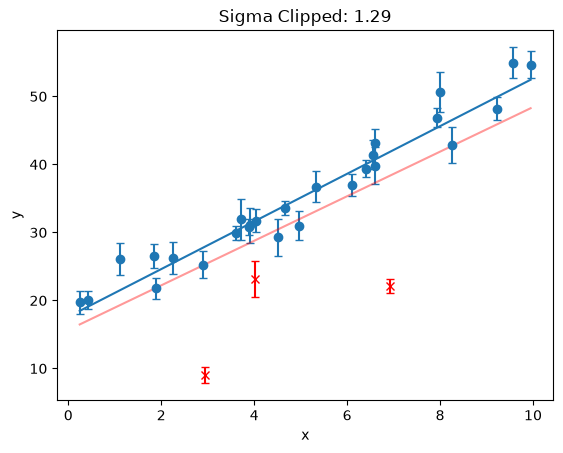

In [27]:
#Method 1 Sigma Clipping
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter = 10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w= 1/sigma[mask], cov=True)
        resid = (y - np.polyval(p,x))/ sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask, cov

p_clip, mask, cov = sigma_clip_fit(x, y, sigma_y, k=3.0)
resid = y[mask] - np.polyval(p_clip, x[mask])
chi2_red_clip = np.sum((resid/sigma_y[mask])**2) / (mask.sum() - 2)

sigma_m = np.sqrt(cov[0,0])
sigma_b = np.sqrt(cov[1,1])

print('m: ', p_clip[0])
print('m +-: ', sigma_m)
print('b: ', p_clip[1])
print('b +-: ', sigma_b)
print('reduced chi-squared: ', chi2_red_clip)
print('number clipped: ', (~mask).sum())

plt.errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize = 3, color='C0', label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize = 3, color='r', label='clipped')
plt.plot(xx, np.polyval(p, xx), 'r-', alpha = 0.4, label = 'initial fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0-', label = 'clipped fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Sigma Clipped: {chi2_red_clip:.2f}')
plt.show()

m: 3.5123760319662867
m +-:  0.16923587582085123
b: 17.54161965259182
b +-:  0.9184585894337314
outlier fraction: 0.11519838154823646


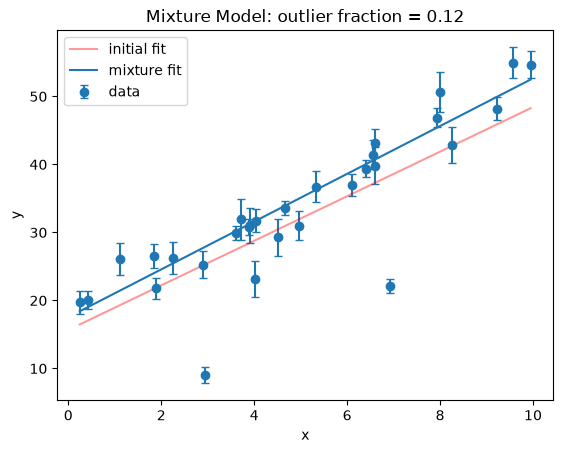

In [33]:
#Method 2 Mixture Model

def mixture(theta, x, y, sigma_y):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1-1e-6)
    Vb = np.exp(lnVb)
    model = m*x + b
    good = (1-Pb) * norm.pdf(y, loc=model, scale=sigma_y)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale =np.sqrt(Vb + sigma_y**2))
    return -np.sum(np.log(good+ bad_pop + 1e-300))

theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50)]
result = minimize(mixture, theta0, args = (x,y,sigma_y), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x



m_boot = []
b_boot = []

rng = np.random.default_rng(42)

for i in range(500):
    inds = rng.choice(len(x), len(x), replace=True)

    xb = x.iloc[inds].to_numpy()
    yb = y.iloc[inds].to_numpy()
    sb = sigma_y.iloc[inds].to_numpy()

    result_b = minimize(
        mixture,
        theta0,
        args=(xb, yb, sb),
        method='Nelder-Mead'
    )

    if result_b.success:
        m_boot.append(result_b.x[0])
        b_boot.append(result_b.x[1])

sigma_m_mix = np.std(m_boot)
sigma_b_mix = np.std(b_boot)


print("m:", m_mix)
print('m +-: ', sigma_m_mix)
print("b:", b_mix)
print('b +-: ', sigma_b_mix)
print("outlier fraction:", Pb_mix)

plt.errorbar(x, y, yerr= sigma_y, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(p, xx), 'r-', alpha=0.4, label= 'initial fit')
plt.plot(xx, m_mix*xx + b_mix, 'C0-', label = 'mixture fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Mixture Model: outlier fraction = {Pb_mix:.2f}')
plt.legend()
plt.show()

**FINAL ANSWER:** $m = $ 3.51 $\pm$ 0.169 , $b = $ 17.54 $\pm$ 0.918 , outlier fraction $\approx$ 0.115

**Justification and uncertainty method (a short paragraph):**

I would choose the Mixture Model over the 3-Sigma-Clipping. While both fits yield almost identical results, the 3-Sigma-Clipping model finds points that are 3sigma or greater and throws them away, while the Mixture model predicts that the outliers are likely to be outliers. I prefer to keep as much data as possible, so keeping those outliers is good. 


For the chosen model, the uncertainty came from the model's probability to create weights, which then was used to estimate the uncertainty like I did in Part 1 and Part 2.2, using the np.polyfit to pull the cov and then to square its respective covariance matrix. 

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* 
Here: 
scale = np.sqrt(chi2_red)
sigma_scaled = sigma_y * scale
The code forces chi^2 to be scaled to one. That means the error bars are artificially increased to ensure that chi^2 is scaled to one. 

The best treatment is to take the scaling sections out of the data.

*Flaw 2:*

Here:
residuals = y - (m_fit * x + b_fit)
threshold = 3 * np.std(residuals)
In these lines, np.std(residuals) represents the global standard deviation, while the code in my Part 2 uses the specific sigma_y values. This does not take into account sigma_y, which means the code does not take into account the precision of each individual measurement. 

To fix this, you should use sigma_y for each one rather than calculate the standard devation and multiply it by 3.
So: mask = np.abs(resid/sigma_y) > 3

*Flaw 3:*

Here: 
m_err, b_err = m_err * scale, b_err * scale
The error bars are getting scaled greater again. These scalings bring up the level of the error bars artificially, which is unnecessary and incorrect. 

The cov diag calculation already yields the error bars, and they should have stuck to that rather than scale it twice. 

In [ ]:
# Part 3: demonstrations here

In [41]:
#Flaw 1:

#AI: Cleaned fit: m = 3.5719 +/- 0.2078, b = 17.1038 +/- 1.1690
#Me: m = 3.503 +/- 0.1443, b = 17.6038 +-0.7665

error_m = 0.2078 - 0.1443
print('difference in error m:', error_m)
error_b = 1.1690 - 0.7665
print('difference in error b:', error_b)
# These errors are significantly higher from the AI solution. 

difference in error m: 0.0635
difference in error b: 0.4025000000000001


In [59]:
#Flaw 2

coeffs, cov = np.polyfit(x, y, 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))
residuals = y - (m_fit * x + b_fit)
mask = np.abs(residuals) > 3 * np.std(residuals)
print(mask.sum())


2


In [54]:
mask = np.abs(resid/sigma_y) > 3
print(mask.sum())

0


In [61]:
#Flaw 3

chi2 = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_y[mask])**2)
dof = mask.sum() - 2
chi2_red = chi2 / dof
scale = np.sqrt(chi2_red)
m_err, b_err = m_err * scale, b_err * scale
print(scale)

#Me: m = 3.503 +/- 0.1443, b = 17.6038 +-0.7665


inf


/var/folders/51/t7p0d3qn31zbytwh8bdmcfk80000gn/T/ipykernel_22519/1592472323.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  chi2_red = chi2 / dof


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

*your answer goes here*

Whenever I report AI use, I tend to just make a note as I go along rather than write a paragraph at the end of the homework to make sure I mention every use.

1) I used ChatGPT:

I forgot the tools of the Pandas library and needed a reminder. Specifically, how to get a csv file.
I had an issue with the Pandas library not being installed and needed assistance figuring that out and installing it. Same issue happened later with matplotlib. Same issue happened with scipy.

Asked: What is the equation for weighted least squares? Asked for an example. Gave it code from lecture 1 to verify that I was looking at the right thing.

Asked: How do I access data using pandas? 

Asked if I could use the code from class (Reduced Chi-Squared Statistic) as a template for the code I would write here-->yes.

I asked ChatGPT how to calculate the errors and used it in Part 1. 

I did not catch anything that ChatGPT did wrong for Part 1.  

2) I used ChatGPT:

The function sigma_clip_fit I have comes directly from lecture. I asked ChatGPT to explain it to me so I understood it better. 

I also used the other code in class and wrote the 3-sigma clipping code based on that. 

I had a weird thing where my number clipped was -28, I gave it to ChatGPT and I had a syntax error. 

I copied and pasted my code into ChatGPT for the sigma-clipping to verify that I had it right.

For the Mixture function, I used Lecture 1 as a template. I pasted what I wrote here into ChatGPT to catch my syntax errors. 

For the Mixture section, I asked ChatGPT to draft the sections of the Lecutre 1 code I needed after the mixture function, and the uncertainty calculations. 

3)
Asked ChatGPT for a refresher on chi^2.


I found a piece of code that was confusing that I suspected was one of the flaws, and asked ChatGPT there was a reason why one might scale chi^2 down to one. Turns out there is not a reason.

Asked ChatGPT about residuals and thresholds. 
Asked ChatGPT about scaling necessities--turns out there is not a reason to scale the errors.

End: Asked ChatGPT for help submitting assignment.

**VERIFICATION PLAN:**

1)
For this check, I compared my results and fit to the results that Lecture 1. It looked as expected, with major outliers.
Failure, as I got here, was a major chi^2.

2)
From Part 1, I knew that there were 2-3 points that were going to be removed from this method. From a visual inspection, that is what I found. In addition, I compared this result to Lecture 1, and found mine to be consistent.
Failure would have been getting a large chi^2.


3)
With Part 1 and Part 2.1, I knew that I should expect 2-3 points to be denoted as outliers, meaning that my m and b values should be quite similar. My m values were off by about 0.01, so it was consistent with 2.
Failure may have looked like too many points being deemed as outliers in the data.


*your answer goes here*